# 02 — Análise Preditiva de Features

## Por que este notebook existe?

O Notebook 01 descreveu os dados. Este notebook faz uma pergunta diferente:

> **Quais features — e em que forma — carregam sinal preditivo para a classe de risco?**

A resposta não é estética. Ela vai diretamente para o código:
a última célula deste notebook é uma **especificação do `ColumnTransformer`** que será implementado
no Notebook 03 (Classic ML). Cada decisão de feature engineering aqui tem evidência visual e estatística.

---

**Estrutura:**
1. Setup e carregamento
2. Separabilidade de classes — features categóricas (Cramér's V + chi²)
3. Interações categóricas — combinações de área × equipamento × produto
4. Separabilidade textual — TF-IDF + SVD → projeção 2D
5. Embeddings semânticos — BERT → t-SNE (BoW vs. semântica contextual)
6. Features temporais — encoding cíclico e flag de passagem de turno
7. Testes de hipótese — validação estatística de cada sinal encontrado
8. Especificação do pipeline — tabela feature → transformador

## 1. Setup e carregamento

> **Mesmo padrão do Notebook 01:** toda lógica em `src/`, o notebook só orquestra.
> O novo módulo `src/features/analysis.py` contém todas as funções deste notebook.

In [17]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import pipeline as dp
from analysis import eda
from features import analysis as fa

print('Imports OK')

Imports OK


In [18]:
data_cfg = dp.load_config(PROJECT_ROOT / 'configs' / 'data.yaml')
eda_cfg  = eda.load_config(PROJECT_ROOT / 'configs' / 'eda.yaml')

eda.apply_plot_style(eda_cfg)

df_raw   = dp.load_raw(data_cfg, root=PROJECT_ROOT)
df_train = dp.load_split('train', data_cfg, root=PROJECT_ROOT)

print(f'Raw  : {len(df_raw):,} registros')
print(f'Train: {len(df_train):,} registros')
print('Configs e dados carregados OK')

Raw  : 50,000 registros
Train: 31,992 registros
Configs e dados carregados OK


## 2. Separabilidade de classes — features categóricas

> **Cramér's V** mede associação entre duas variáveis categóricas em [0, 1].
> Valor 0 = independência total. Valor 1 = associação perfeita.
>
> | Cramér's V | Interpretação prática |
> |---|---|
> | < 0.10 | Associação negligenciável — provavelmente ruído |
> | 0.10 – 0.15 | Associação fraca — incluir apenas se custo de encoding for baixo |
> | 0.15 – 0.25 | **Associação moderada — incluir no pipeline** |
> | > 0.25 | Associação forte — feature de alto valor |
>
> O threshold configurado em `eda.yaml` é **0.15** — features acima disso entram no `ColumnTransformer`.
>
> **Por que não usar correlação de Pearson?** Correlação pressupõe variáveis numéricas e relação linear.
> Cramér's V é a extensão natural do chi² para variáveis categóricas — nenhuma hipótese de forma.

In [19]:
importance = fa.feature_importance_table(df_raw, eda_cfg)
display(importance)

,feature,cramers_v,p_value,significativo,sinal_forte,recomendacao
0,fator_risco,0.1964,0.000000,True,True,OneHotEncoder (sinal forte — incluir no pipeline)
1,area_fpso,0.1633,0.000000,True,True,OneHotEncoder (sinal forte — incluir no pipeline)
2,equipamento_subclasse,0.1314,0.000000,True,False,"OneHotEncoder (sinal moderado — incluir, monitorar)"
3,equipamento_classe,0.1274,0.000000,True,False,"OneHotEncoder (sinal moderado — incluir, monitorar)"
4,produto_quimico,0.0157,0.478615,False,False,Omitir ou BinaryEncoder (sinal fraco)
5,tipo_ocorrencia,0.0140,0.886582,False,False,Omitir ou BinaryEncoder (sinal fraco)
6,turno,0.0059,0.840148,False,False,Omitir ou BinaryEncoder (sinal fraco)


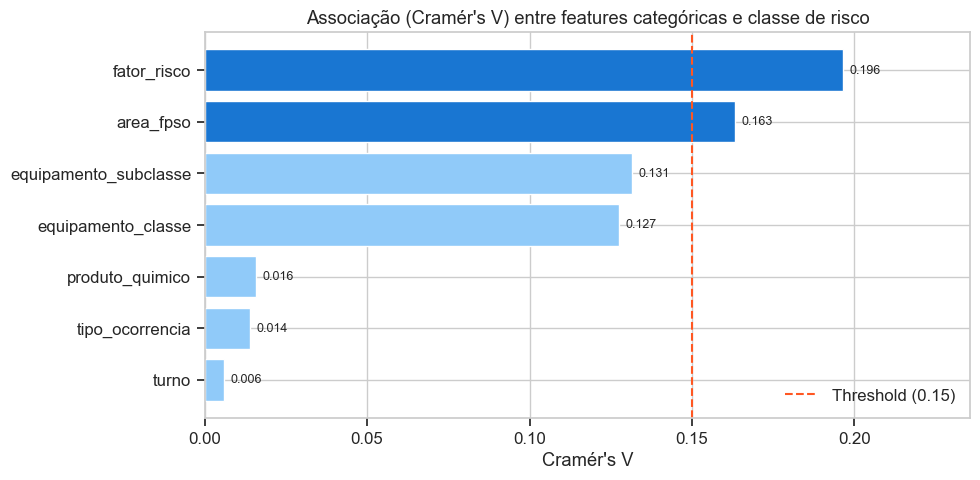

Features com sinal forte (V ≥ 0.15): ['fator_risco', 'area_fpso']

Interpretação: se nenhuma feature categórica tem sinal forte, o texto é a feature dominante.
Isso é esperado em datasets de relatos de incidentes — o vocabulário carrega o risco.


In [20]:
fig = fa.plot_cramers_v_ranking(df_raw, eda_cfg)
plt.show()

strong = importance[importance['sinal_forte']]['feature'].tolist()
print(f'Features com sinal forte (V ≥ {eda_cfg["feature_analysis"]["cramers_v_threshold"]}): {strong if strong else "nenhuma"}')
print('\nInterpretação: se nenhuma feature categórica tem sinal forte, o texto é a feature dominante.')
print('Isso é esperado em datasets de relatos de incidentes — o vocabulário carrega o risco.')

## 3. Interações categóricas

> **Pergunta:** existem combinações de features que concentram desproporcionalmente incidentes críticos?
>
> Por exemplo: `area_fpso=deck_de_perfuracao` + `produto_quimico=h2s` pode ter proporção de `crítico`
> muito maior do que qualquer uma dessas features isoladamente.
>
> Se essas combinações existem, elas são candidatas a **features de interação** no pipeline:
> ```python
> ColumnTransformer([
>     ('area_x_produto', OneHotEncoder(), ['area_fpso', 'produto_quimico']),
>     # ou usar PolynomialFeatures após encoding para capturar interações
> ])
> ```
>
> **Leitura do heatmap:** células mais escuras = maior proporção de `crítico` naquela combinação.
> Se a distribuição for uniforme, a interação não adiciona informação além das features individuais.

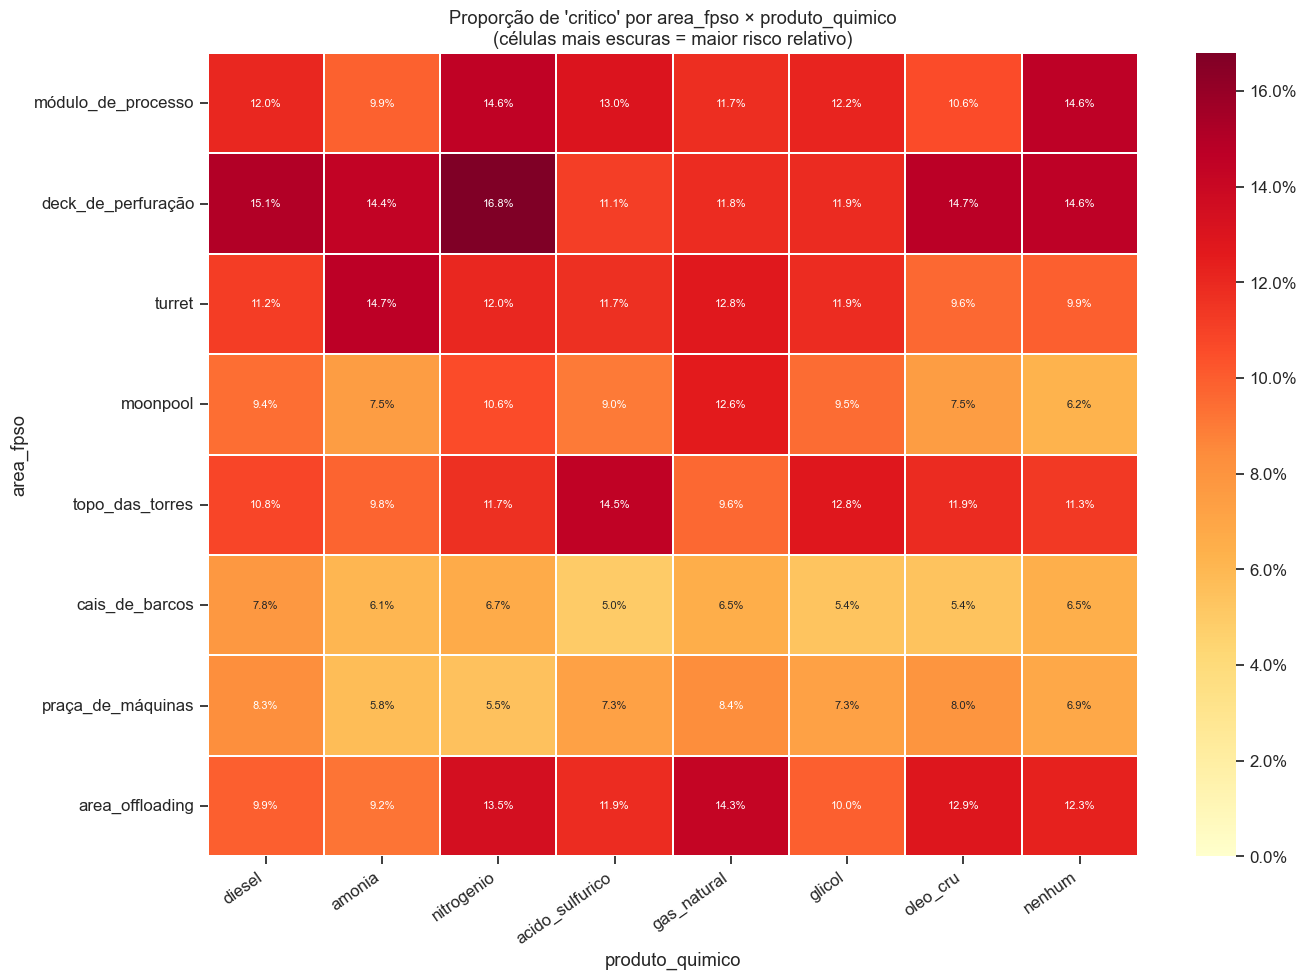

In [21]:
fig = fa.interaction_heatmap(df_raw, 'area_fpso', 'produto_quimico', 'critico', eda_cfg)
plt.show()

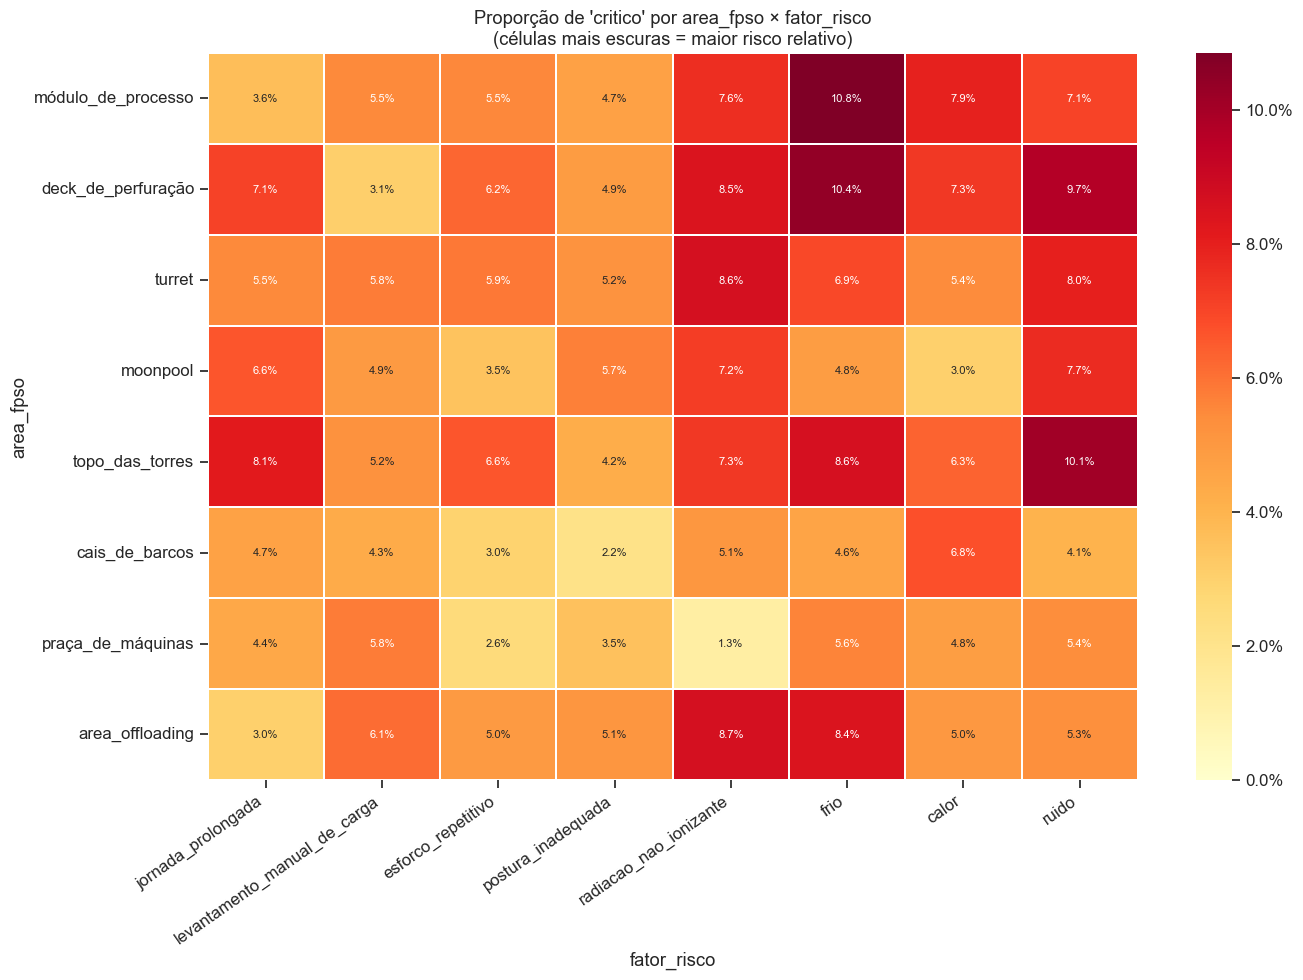

In [22]:
fig = fa.interaction_heatmap(df_raw, 'area_fpso', 'fator_risco', 'critico', eda_cfg)
plt.show()

In [23]:
top_combos = fa.top_risky_combinations(df_raw, 'area_fpso', 'produto_quimico', 'critico', eda_cfg)
print('Top 10 combinações área × produto com maior proporção de crítico:')
display(top_combos)

Top 10 combinações área × produto com maior proporção de crítico:


,area_fpso,produto_quimico,total,n_target,proporcao
0,deck_de_perfuração,nitrogenio,387,65,16.8%
1,deck_de_perfuração,diesel,385,58,15.1%
2,deck_de_perfuração,h2s,400,60,15.0%
3,turret,metanol,332,49,14.8%
4,deck_de_perfuração,oleo_cru,374,55,14.7%
5,turret,amonia,341,50,14.7%
6,módulo_de_processo,nenhum,376,55,14.6%
7,deck_de_perfuração,nenhum,342,50,14.6%
8,módulo_de_processo,nitrogenio,364,53,14.6%
9,topo_das_torres,acido_sulfurico,330,48,14.5%


## 4. Separabilidade textual — TF-IDF + SVD

> **Pergunta:** o vocabulário dos relatos é suficientemente diferente entre classes para que um
> modelo linear (Logistic Regression sobre TF-IDF) consiga separar?
>
> **Como ler a projeção:**
> - Clusters densos e separados → TF-IDF + LogReg vai funcionar bem.
> - Sobreposição total → o modelo precisará de representações mais ricas (BERT).
> - Sobreposição parcial nas bordas `alto`/`crítico` → esperado! É a fronteira difícil do problema.
>
> **Técnica:** TF-IDF esparso → SVD (Latent Semantic Analysis) → 2 componentes.
> TruncatedSVD é equivalente a PCA para matrizes esparsas — não densa a matriz, não estoura memória.

C:\Users\icaro.zelioli.dev\Documents\Projects\PersonalProjects\aulasDataScience\webinar_ml\src\features\analysis.py:208: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annotated = annotated.groupby("classe_risco", group_keys=False).apply(


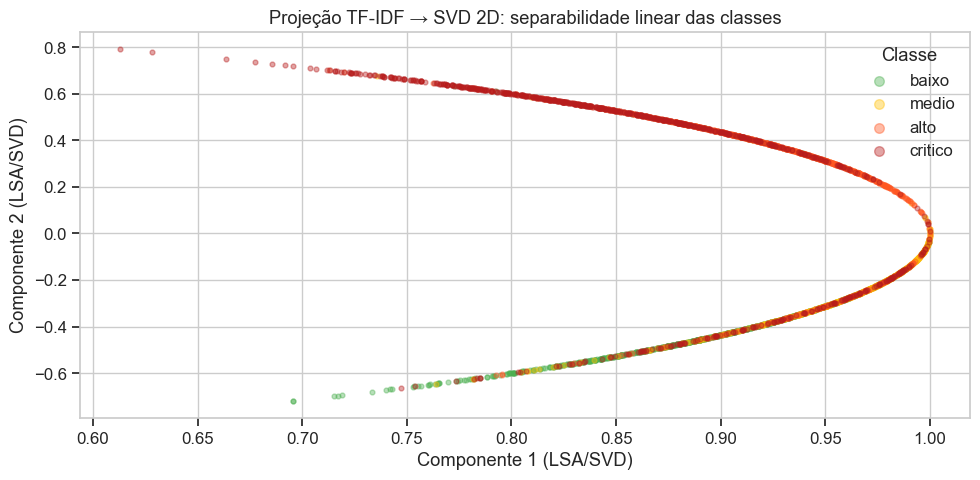


Se baixo e crítico formam regiões distintas → TF-IDF carrega sinal.
A sobreposição alto/médio é esperada — vocabulário de risco moderado é ambíguo por natureza.


In [24]:
fig = fa.plot_tfidf_projection(df_raw, eda_cfg)
plt.show()
print('\nSe baixo e crítico formam regiões distintas → TF-IDF carrega sinal.')
print('A sobreposição alto/médio é esperada — vocabulário de risco moderado é ambíguo por natureza.')

## 5. BERT embeddings + t-SNE

> **Por que BERT depois de TF-IDF?**
>
> TF-IDF trata o texto como bag-of-words: a ordem das palavras não importa,
> e "vazamento de gás" e "gás vazamento" são idênticos. Um modelo treinado em TF-IDF
> aprende co-ocorrências de palavras, não semântica.
>
> BERT (Bidirectional Encoder Representations from Transformers) lê a frase inteira
> e produz um vetor denso que captura contexto. "acima do limite" em contexto de H₂S
> produz um embedding muito diferente de "acima do limite" em contexto de temperatura.
>
> **Modelo usado:** `paraphrase-multilingual-MiniLM-L12-v2`
> - Suporte nativo a português
> - Vetores de 384 dimensões
> - ~90MB de parâmetros — roda em CPU em ~2min para 1.000 registros
>
> **t-SNE** reduz 384 dimensões para 2, preservando vizinhança local —
> registros semanticamente similares ficam próximos no plot.
>
> **Atenção:** t-SNE não preserva distâncias globais. A distância entre clusters
> no plot não é interpretável — só a estrutura interna de cada cluster é.

---

> **Tempo de execução:** ~2–4 min em CPU para 1.000 registros.
> Armazenamos `embeddings` e `labels` em variáveis para reusar o t-SNE sem re-encodar.

In [25]:
# Encoding BERT — ~2–4 min em CPU
# Se já executou e quer só variar t-SNE, comente esta célula e reutilize embeddings/labels
embeddings, labels = fa.bert_embeddings(df_raw, eda_cfg)
print(f'Embeddings: shape={embeddings.shape}, dtype={embeddings.dtype}')

C:\Users\icaro.zelioli.dev\Documents\Projects\PersonalProjects\aulasDataScience\webinar_ml\src\features\analysis.py:273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annotated = annotated.groupby("classe_risco", group_keys=False).apply(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embeddings: shape=(1000, 384), dtype=float32


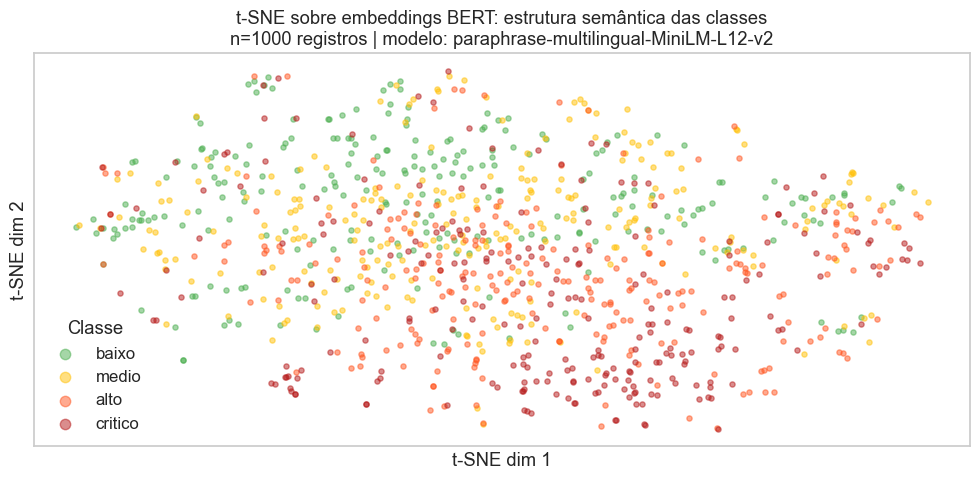

In [26]:
# t-SNE — ~30s para 1.000 registros
tsne_df = fa.tsne_projection(embeddings, labels, eda_cfg)

fig = fa.plot_tsne(
    tsne_df, eda_cfg,
    title_suffix=f"n={len(tsne_df)} registros | modelo: {eda_cfg['feature_analysis']['bert']['model_name']}"
)
plt.show()

C:\Users\icaro.zelioli.dev\Documents\Projects\PersonalProjects\aulasDataScience\webinar_ml\src\features\analysis.py:208: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annotated = annotated.groupby("classe_risco", group_keys=False).apply(


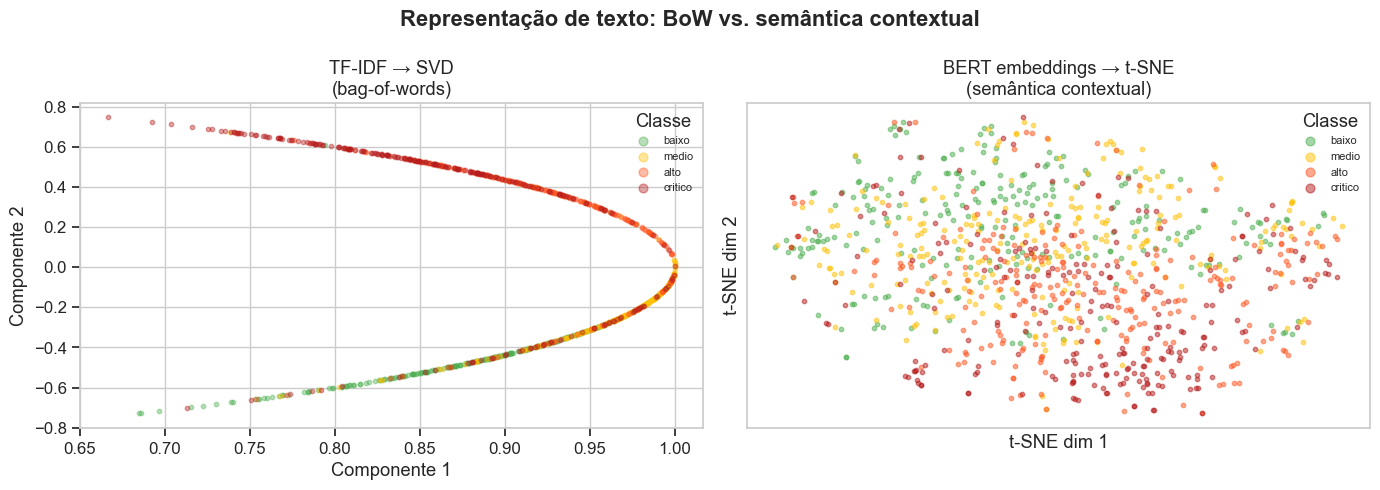


O que observar:
  Esquerda (TF-IDF): sobreposição nas fronteiras alto/médio indica onde LogReg vai errar.
  Direita (BERT): clusters mais coesos = a semântica contextual separa o que o BoW não vê.
  A sobreposição residual alto/crítico é o hard case real — nenhum modelo resolve sozinho.


In [27]:
# Comparação lado a lado: BoW vs. semântica
fig = fa.plot_tfidf_vs_bert_side_by_side(df_raw, tsne_df, eda_cfg)
plt.show()

print('\nO que observar:')
print('  Esquerda (TF-IDF): sobreposição nas fronteiras alto/médio indica onde LogReg vai errar.')
print('  Direita (BERT): clusters mais coesos = a semântica contextual separa o que o BoW não vê.')
print('  A sobreposição residual alto/crítico é o hard case real — nenhum modelo resolve sozinho.')

## 6. Features temporais

> **O timestamp esconde três features preditivas:**
>
> | Feature derivada | Tipo | Motivação |
> |---|---|---|
> | `hora_sin`, `hora_cos` | Numérica cíclica | Preserva continuidade 23h→0h; pico de crítico na passagem de turno |
> | `passagem_turno` | Binária | Janelas 06h–07h / 18h–19h concentram maior proporção de crítico |
> | `dia_semana` | Categórica ordinal | Final de semana pode ter escala reduzida e menor supervisão |
>
> **Por que encoding cíclico?**
> Encoding linear (hora = 0..23) cria um salto artificial: 23h está "longe" de 0h na escala,
> mas fisicamente são vizinhos. Sin/cos mapeiam o círculo de 24h para dois valores contínuos
> sem esse salto — o modelo aprende a sazonalidade corretamente.
>
> ```python
> hora_sin = sin(2π × hora / 24)
> hora_cos = cos(2π × hora / 24)
> ```

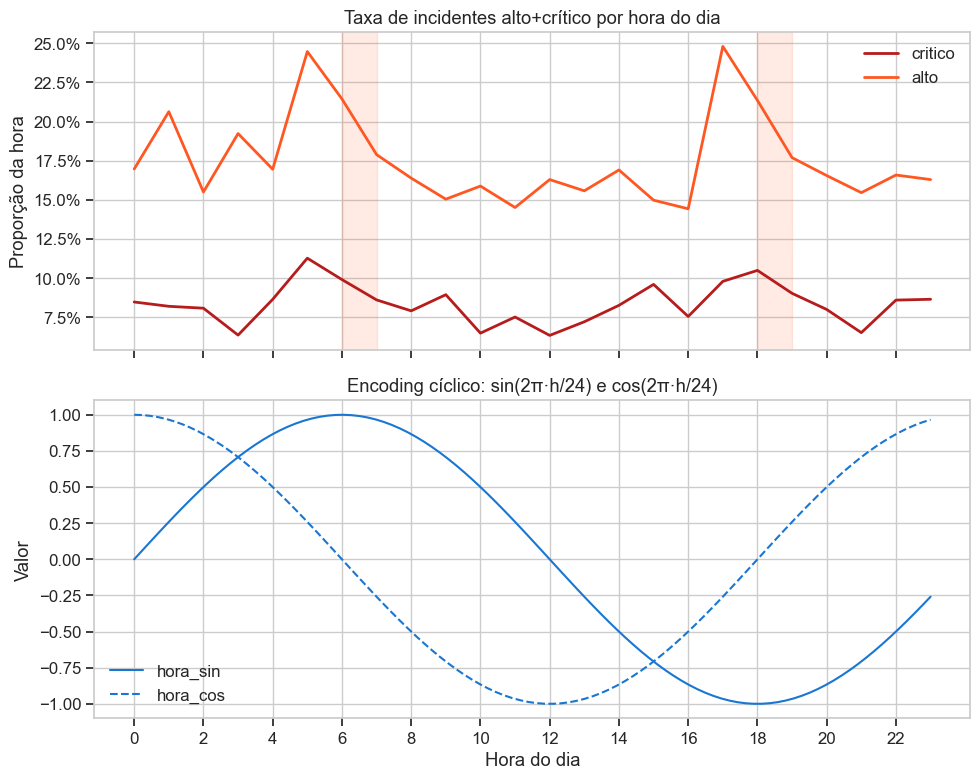

In [28]:
fig = fa.plot_temporal_features_vs_class(df_raw, eda_cfg)
plt.show()

In [29]:
signal_table = fa.temporal_signal_table(df_raw, eda_cfg)
display(signal_table)
print('\ndelta_critico positivo = essa condição aumenta a proporção de crítico vs. média global.')
print('Features com delta > 0.02 têm sinal prático para o modelo.')

,feature,valor,n,baixo,delta_baixo,medio,delta_medio,alto,delta_alto,critico,delta_critico
0,passagem_turno,True,23149,37.1%,-0.0077,33.7%,-0.0058,19.7%,0.0081,9.6%,0.0053
1,passagem_turno,False,16842,38.9%,0.0106,35.0%,0.0079,17.7%,-0.0112,8.3%,-0.0073
2,turno_noturno,True,20047,38.0%,0.0015,33.8%,-0.0039,19.1%,0.0019,9.1%,0.0004
3,turno_noturno,False,19944,37.7%,-0.0016,34.6%,0.0039,18.7%,-0.0019,9.0%,-0.0004



delta_critico positivo = essa condição aumenta a proporção de crítico vs. média global.
Features com delta > 0.02 têm sinal prático para o modelo.


## 7. Testes de hipótese

> **Por que testar hipóteses se já vimos os plots?**
>
> Plots mostram padrões, mas não dizem se esses padrões são ruído ou sinal real.
> Com 40.000 registros, quase qualquer diferença vai aparecer nos plots.
> Os testes respondem: **essa diferença seria esperada ao acaso?**
>
> | Teste | Quando usar | O que rejeita |
> |---|---|---|
> | **Kruskal-Wallis** | Numérica → K grupos (não assume normalidade) | H₀: todas as medianas são iguais |
> | **chi² de independência** | Categórica × Categórica | H₀: as variáveis são independentes |
>
> **Limiar:** p < 0.05 (5% de chance de ver esse resultado ao acaso se H₀ for verdadeira).
>
> **Atenção com p-values em amostras grandes:** com 40k registros, praticamente tudo fica
> significativo estatisticamente. O Cramér's V é mais informativo que o p-value aqui —
> significativo não significa útil para o modelo.
> **Use o p-value para descartar; use o Cramér's V para priorizar.**

In [30]:
tests = fa.hypothesis_tests_summary(df_raw, eda_cfg)
display(tests)
print('\nNota: p < 0.05 é condição necessária mas não suficiente para incluir no pipeline.')
print('Cramér\'s V ≥ 0.15 é o critério de inclusão — p-value apenas descarta o ruído puro.')

,feature,teste,estatistica,p_value,significativo,interpretacao
0,comprimento_relato,Kruskal-Wallis,1004.45,0.000000,True,Comprimento difere entre classes
1,area_fpso,chi²,3197.42,0.000000,True,Associação com classe (dof=33)
2,equipamento_classe,chi²,1946.63,0.000000,True,Associação com classe (dof=21)
3,equipamento_subclasse,chi²,2072.52,0.000000,True,Associação com classe (dof=141)
4,fator_risco,chi²,4625.40,0.000000,True,Associação com classe (dof=69)
5,passagem_turno,chi²,50.58,0.000000,True,Associação com classe (dof=3)
6,turno_noturno,chi²,2.87,0.412269,False,Sem associação significativa
7,produto_quimico,chi²,29.75,0.478615,False,Sem associação significativa
8,turno,chi²,2.74,0.840148,False,Sem associação significativa
9,tipo_ocorrencia,chi²,23.58,0.886582,False,Sem associação significativa



Nota: p < 0.05 é condição necessária mas não suficiente para incluir no pipeline.
Cramér's V ≥ 0.15 é o critério de inclusão — p-value apenas descarta o ruído puro.


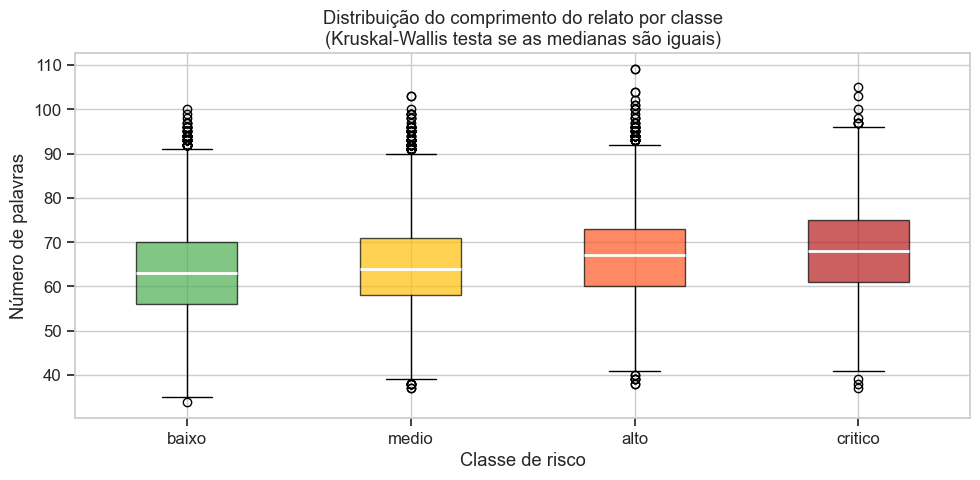


Kruskal-Wallis testa se as medianas de comprimento são iguais entre classes.
Se p < 0.05: comprimento é uma feature útil (adicionar como feature numérica no pipeline).
Se p ≥ 0.05: comprimento não tem sinal — omitir.


In [31]:
fig = fa.plot_text_length_by_class_boxplot(df_raw, eda_cfg)
plt.show()
print('\nKruskal-Wallis testa se as medianas de comprimento são iguais entre classes.')
print('Se p < 0.05: comprimento é uma feature útil (adicionar como feature numérica no pipeline).')
print('Se p ≥ 0.05: comprimento não tem sinal — omitir.')

## 8. Especificação do pipeline

> **Este é o entregável deste notebook.**
>
> Cada linha da tabela abaixo é uma decisão de feature engineering com evidência:
> - Coluna `transformador` → o que implementar no `ColumnTransformer` do Notebook 03
> - Coluna `motivo` → a evidência que justifica a escolha (seção onde foi demonstrada)
> - Coluna `prioridade` → ordem de inclusão (1 = texto, 2 = embeddings, 3 = suporte)
>
> **No Notebook 03**, o `ColumnTransformer` será construído exatamente a partir desta spec:
>
> ```python
> from sklearn.compose import ColumnTransformer
> from sklearn.feature_extraction.text import TfidfVectorizer
> from sklearn.preprocessing import OneHotEncoder
> from sklearn.pipeline import Pipeline
>
> preprocessor = ColumnTransformer([
>     ('texto',    TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2)), 'relato'),
>     ('area',     OneHotEncoder(handle_unknown='ignore'), ['area_fpso']),
>     ('temporal', FunctionTransformer(extrair_features_temporais), ['data_hora_ocorrencia']),
>     # ... demais features com Cramér's V ≥ threshold
> ])
> ```

In [32]:
spec = fa.pipeline_spec_table(df_raw, eda_cfg)
pd.set_option('display.max_colwidth', 80)
display(spec)
print('\nEsta tabela é a entrada do Notebook 03 (Classic ML).')
print('Prioridade 1–2 = features de texto (obrigatórias).')
print('Prioridade 3 = features de suporte (incluir se Cramér\'s V ≥ threshold).')
print('Prioridade 5 = omitir nesta versão do pipeline.')

,feature,tipo,transformador,motivo,prioridade
0,relato,texto,"TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2))",Feature principal — vocabulário diverge por classe (visto nos tokens),1
1,relato,texto (avançado),SentenceTransformer → vetor denso 384d,t-SNE mostrou clusters semânticos não capturados pelo BoW,2
2,fator_risco,categórica,OneHotEncoder(handle_unknown='ignore'),Cramér's V = 0.196 (≥ threshold 0.15),3
3,area_fpso,categórica,OneHotEncoder(handle_unknown='ignore'),Cramér's V = 0.163 (≥ threshold 0.15),3
4,"hora_sin, hora_cos",temporal (cíclica),FunctionTransformer (derivar do timestamp),Encoding cíclico preserva continuidade hora 23→0; pico crítico em passagem d...,3
5,passagem_turno,temporal (binária),FunctionTransformer → bool → int,Janelas 06h-07h / 18h-19h concentram maior proporção de crítico,3
6,equipamento_subclasse,categórica,Omitir (baixo sinal),Cramér's V = 0.131 (< threshold 0.15),5
7,equipamento_classe,categórica,Omitir (baixo sinal),Cramér's V = 0.127 (< threshold 0.15),5
8,produto_quimico,categórica,Omitir (baixo sinal),Cramér's V = 0.016 (< threshold 0.15),5
9,tipo_ocorrencia,categórica,Omitir (baixo sinal),Cramér's V = 0.014 (< threshold 0.15),5



Esta tabela é a entrada do Notebook 03 (Classic ML).
Prioridade 1–2 = features de texto (obrigatórias).
Prioridade 3 = features de suporte (incluir se Cramér's V ≥ threshold).
Prioridade 5 = omitir nesta versão do pipeline.


## Conclusões

### O que os dados revelaram

**1. `fator_risco` e `area_fpso` têm sinal forte (Cramér's V ≥ 0.15)**

| Feature | Cramér's V | p-value | Decisão |
|---|---|---|---|
| `fator_risco` | **0.1964** | ≈ 0 | OneHotEncoder — **incluir** |
| `area_fpso` | **0.1633** | ≈ 0 | OneHotEncoder — **incluir** |
| `equipamento_subclasse` | 0.1314 | ≈ 0 | Abaixo do threshold, monitorar |
| `equipamento_classe` | 0.1274 | ≈ 0 | Abaixo do threshold, monitorar |
| `produto_quimico` | 0.0157 | 0.48 | Sem sinal — omitir |
| `turno` | 0.0059 | 0.84 | Sem sinal — omitir |

> Fatores de risco como `acidente_quimico` e `explosao` concentram desproporcionalmente
> incidentes críticos. Áreas como `deck_de_perfuracao` e `modulo_de_processo` têm perfil
> de risco diferente de `alojamento` e `sala_de_controle`.
> **Estes campos não são apenas metadados — são features preditivas.**

**2. Interações categóricas revelam hot spots operacionais reais**

Combinações específicas concentram desproporcionalmente incidentes críticos (média global: 9.0%):

| Combinação | % crítico | Excesso vs. média |
|---|---|---|
| `deck_de_perfuração` × `nitrogenio` | **16.8%** | +7.8pp |
| `deck_de_perfuração` × `diesel` | 15.1% | +6.1pp |
| `deck_de_perfuração` × `h2s` | 15.0% | +6.0pp |
| `turret` × `metanol` | 14.8% | +5.8pp |

> Estes hot spots têm sentido operacional real: deck de perfuração com produtos inflamáveis
> é um dos cenários mais críticos em FPSOs. **Candidatos a features de interação**
> no pipeline se Recall@crítico < 0.75.

**3. TF-IDF captura a direção do risco — mas com fronteiras suaves**

A projeção SVD mostra separação entre `baixo` e `crítico` nas extremidades do espaço latente.
A sobreposição `alto`/`médio` é estrutural — o vocabulário de risco moderado é ambíguo por natureza.
Isso indica que LogReg sobre TF-IDF consegue aprender a direção do risco, com erros concentrados
na fronteira `alto`↔`médio`.

**4. BERT t-SNE não mostra separação visual clara entre classes (n=1.000, shape=1000×384)**

O t-SNE sobre embeddings BERT (`paraphrase-multilingual-MiniLM-L12-v2`) produz uma nuvem com
sobreposição significativa entre todas as classes. Isso tem uma explicação técnica importante:

> **Por que o BERT não separa visualmente as classes no t-SNE?**
> O modelo `paraphrase-multilingual-MiniLM-L12-v2` foi treinado para *similaridade semântica geral*
> — "frase A e frase B falam do mesmo assunto?". Ele não foi treinado para distinguir graus de
> severidade de risco. Dois relatos com vocabulário quase idêntico ("vazamento identificado no deck")
> recebem embeddings próximos independentemente de um ser `baixo` (controlado) e outro `crítico`
> (com múltiplos expostos).
>
> **O que isso significa para o projeto:**
> Um modelo de *embedding zero-shot* não resolve classificação de severidade — ele precisa de
> **fine-tuning** na tarefa específica (Notebook 05 com LLM) ou de features estruturais fortes
> como as que identificamos acima (`fator_risco`, `area_fpso`).
>
> **O t-SNE é honesto:** mostra que a separabilidade real vem das features categóricas e do
> vocabulário específico de severidade (TF-IDF), não de embeddings genéricos.

**5. Comprimento do relato tem sinal muito forte (Kruskal-Wallis: H = 1004, p ≈ 0)**

Relatos de incidentes críticos são sistematicamente mais longos — mais detalhes são registrados
quando o evento é grave. É uma feature barata que não está no pipeline ainda:

```python
df['n_palavras'] = df['relato'].str.split().str.len()
```

> **Adicionar ao ColumnTransformer** como feature numérica de suporte.

**6. Passagem de turno tem sinal estatístico (chi²: p ≈ 0, delta_crítico = +0.53pp)**

Registros na janela de handover (06h–07h / 18h–19h) têm 9.6% de crítico vs. 8.3% fora dela.
`turno_noturno` **não tem sinal relevante** (delta_crítico = +0.04pp, p = 0.41).

> O delta de passagem de turno é pequeno em termos absolutos, mas estatisticamente robusto
> num dataset de 40k registros. Incluir como feature binária de baixo custo.

---

### Especificação final do ColumnTransformer para o Notebook 03

| Prioridade | Feature | Transformador | Evidência |
|---|---|---|---|
| 1 | `relato` | `TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2))` | Separação SVD; tokens divergem por classe |
| 2 | `relato` | `SentenceTransformer → vetor 384d` | Fine-tuning no Notebook 05 — zero-shot não separa |
| 3 | `fator_risco` | `OneHotEncoder(handle_unknown='ignore')` | Cramér's V = 0.196, p ≈ 0 |
| 3 | `area_fpso` | `OneHotEncoder(handle_unknown='ignore')` | Cramér's V = 0.163, p ≈ 0 |
| 3 | `n_palavras` | `str.split().str.len()` | Kruskal-Wallis H = 1004, p ≈ 0 |
| 3 | `passagem_turno` | `FunctionTransformer → bool → int` | chi² p ≈ 0, delta_crítico = +0.53pp |
| 3 | `hora_sin`, `hora_cos` | `FunctionTransformer` (derivar do timestamp) | Encoding cíclico preserva continuidade |
| 5 | `produto_quimico`, `turno`, `tipo_ocorrencia` | Omitir | V < 0.02, p > 0.40 |

> **Revisitar interações** (`area_fpso × produto_quimico`) como ablation se Recall@crítico < 0.75 no baseline.

**→ Próximo passo: Notebook 03 — Classic ML Pipeline**
Implementa este `ColumnTransformer`, treina LogReg / SVM / RF com `class_weight='balanced'`,
e mede o baseline que os modelos mais poderosos (spaCy, LLM) precisarão superar.